<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
#!pip install pandas

In [2]:
#!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

### Step 2: Import necessary libraries and load the dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

### Load the data


In [4]:
df = pd.read_csv(r"C:\Users\lenovo-miguel\OneDrive\IBM_Data_Analytics_Coursera\survey-data.csv")

### Display the first few rows of the data to understand its structure


In [5]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



(29424, 3)


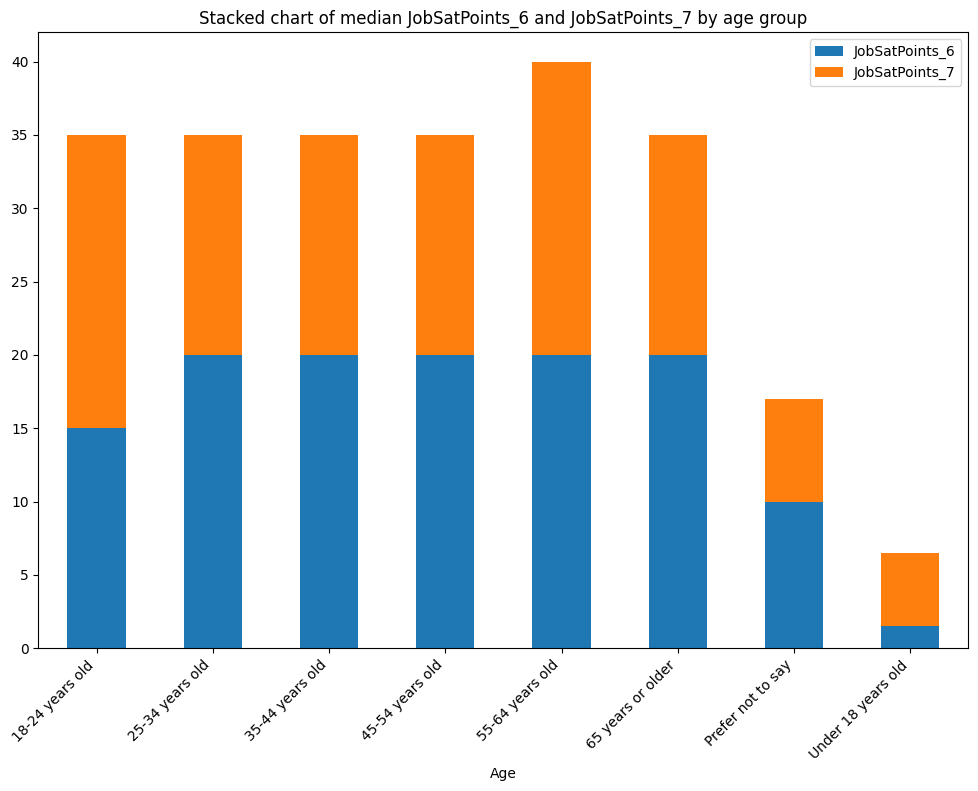

In [6]:
#let's get a specific dataset for this analysis, without missing values
df_age_js = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()
print(df_age_js.shape)
#let's group by age group getting the median of the job satisfaction columns
df_age_js_grouped = df_age_js.groupby('Age')[['JobSatPoints_6', 'JobSatPoints_7']].median()
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
df_age_js_grouped.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Stacked chart of median JobSatPoints_6 and JobSatPoints_7 by age group')
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


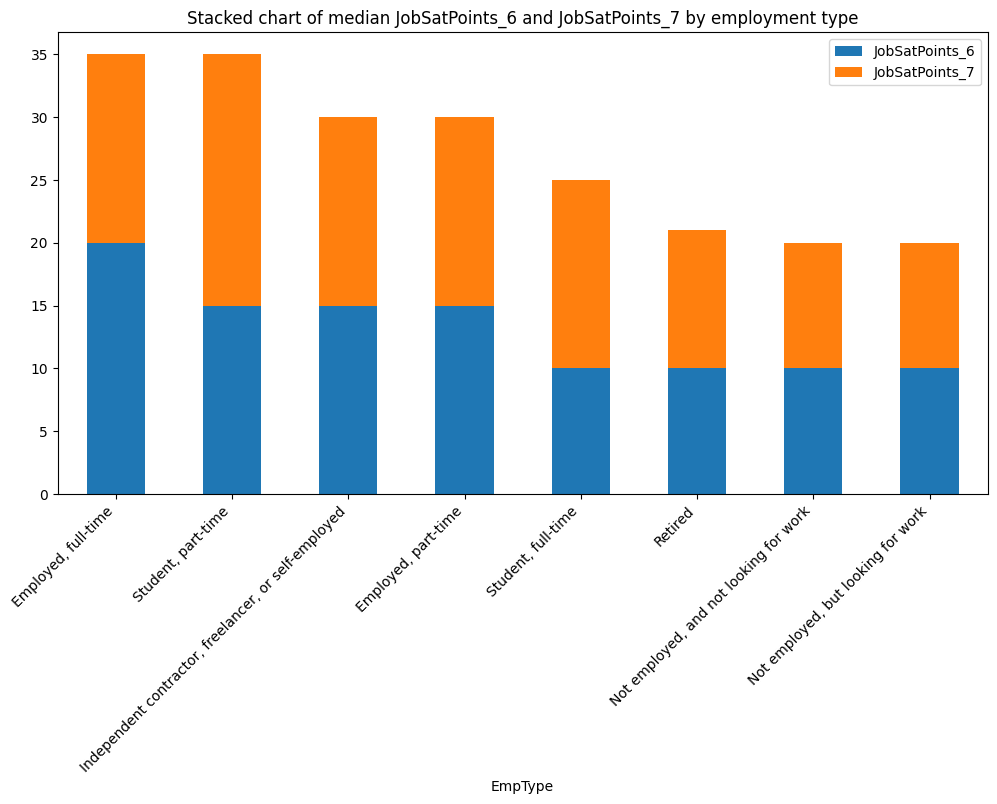

In [7]:
#let's get a specific dataset for this analysis, without missing values
df_emp_js = df[['Employment', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()
#Employment is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_emp_js = df_emp_js.assign(EmpType=df_emp_js['Employment'].str.split(';'))
df_emp_js = df_emp_js.explode('EmpType')
#let's group by employment type getting the median of the job satisfaction columns
df_emp_js_grouped = df_emp_js.groupby('EmpType')[['JobSatPoints_6', 'JobSatPoints_7']].median()
#let's sort the grouped dataframe to have bars plotted on descending height
df_emp_js_grouped['Total'] = df_emp_js_grouped['JobSatPoints_6'] + df_emp_js_grouped['JobSatPoints_7']
df_emp_js_grouped = df_emp_js_grouped.sort_values(by='Total', ascending=False).drop(columns='Total')
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
df_emp_js_grouped.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Stacked chart of median JobSatPoints_6 and JobSatPoints_7 by employment type')
plt.show()

### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


###We have here again the same problem I have found on other labs: Age is not a numerical variable, it is categorical, and its values are age ranges. And there is no '30-35 years old' age range. I will plot the chart for the the '25-34 years old', which is the most approximated to the '30-35' range...

(7431, 3)


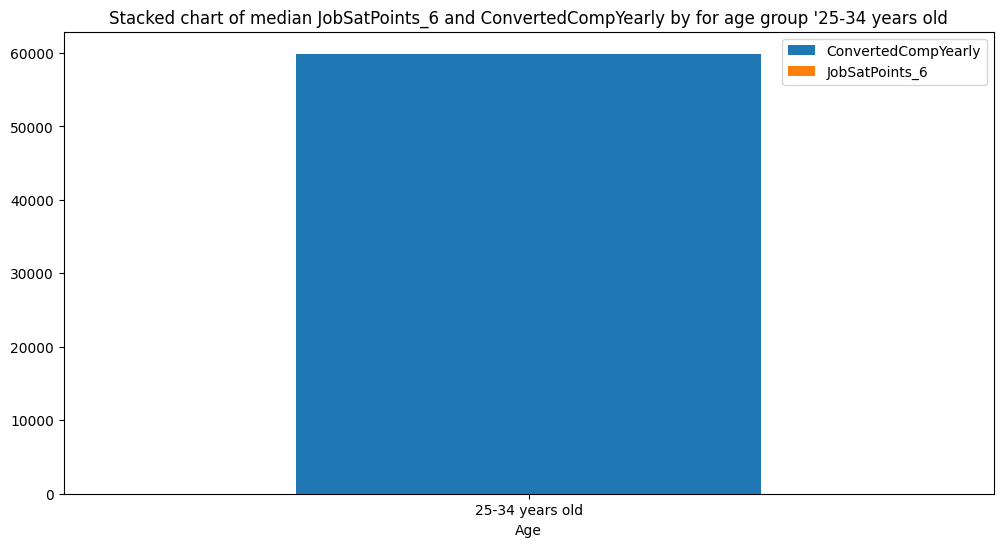

In [8]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js_age = df[['Age', 'JobSatPoints_6', 'ConvertedCompYearly']].dropna()
df_ccy_js_25to34 = df_ccy_js_age[df_ccy_js_age['Age']=='25-34 years old']
print(df_ccy_js_25to34.shape)
#let's group by Age getting the median of the job satisfaction and annual compensation columns
df_ccy_js_25to34_grouped = df_ccy_js_25to34.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
df_ccy_js_25to34_grouped.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
plt.title("Stacked chart of median JobSatPoints_6 and ConvertedCompYearly by for age group '25-34 years old")
plt.show()

###Although it is possible to plot this chart, it does not make sense doing it! ConvertedCompYearly and JobSatPoints6 are measured on different units, it does not make sense to have them added up. And their orders of magnitude are also quite different, we see that job satisfaction actually is not represented at all, it disapears on the y-axis scale. To do the required analysis, a chart with two subplots, one for each variable, is more appropriate, let's do it.

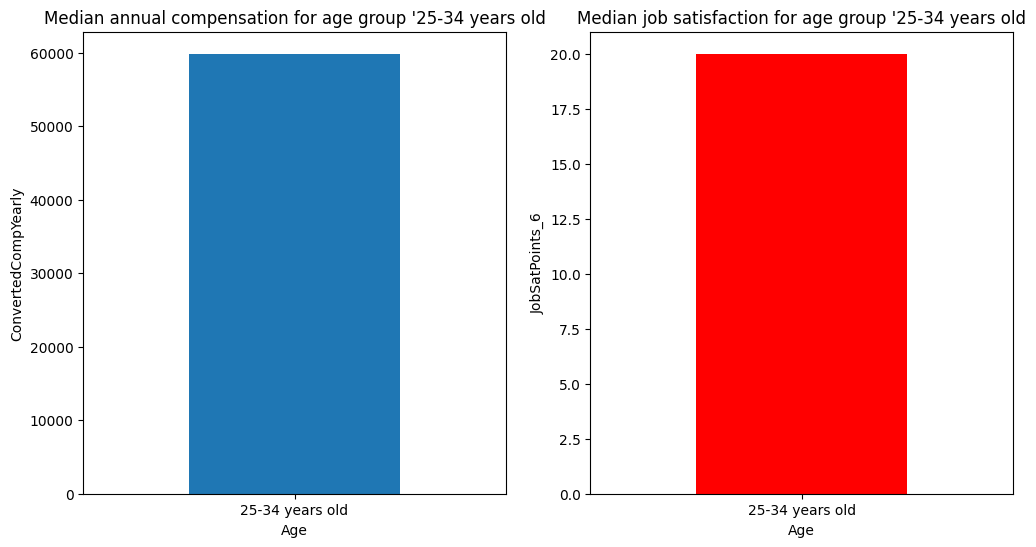

In [9]:
#let's plot the two charts
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
df_ccy_js_25to34_grouped['ConvertedCompYearly'].plot(kind='bar', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='center')
axes[0].set_title("Median annual compensation for age group '25-34 years old")
axes[0].set_ylabel('ConvertedCompYearly')
df_ccy_js_25to34_grouped['JobSatPoints_6'].plot(kind='bar', ax=axes[1], color='red')
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='center')
axes[1].set_title("Median job satisfaction for age group '25-34 years old")
axes[1].set_ylabel('JobSatPoints_6')
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


###By the same reason we have stated above, we will plot two charts to do this analysis. The numerical variables are not homogeneous.

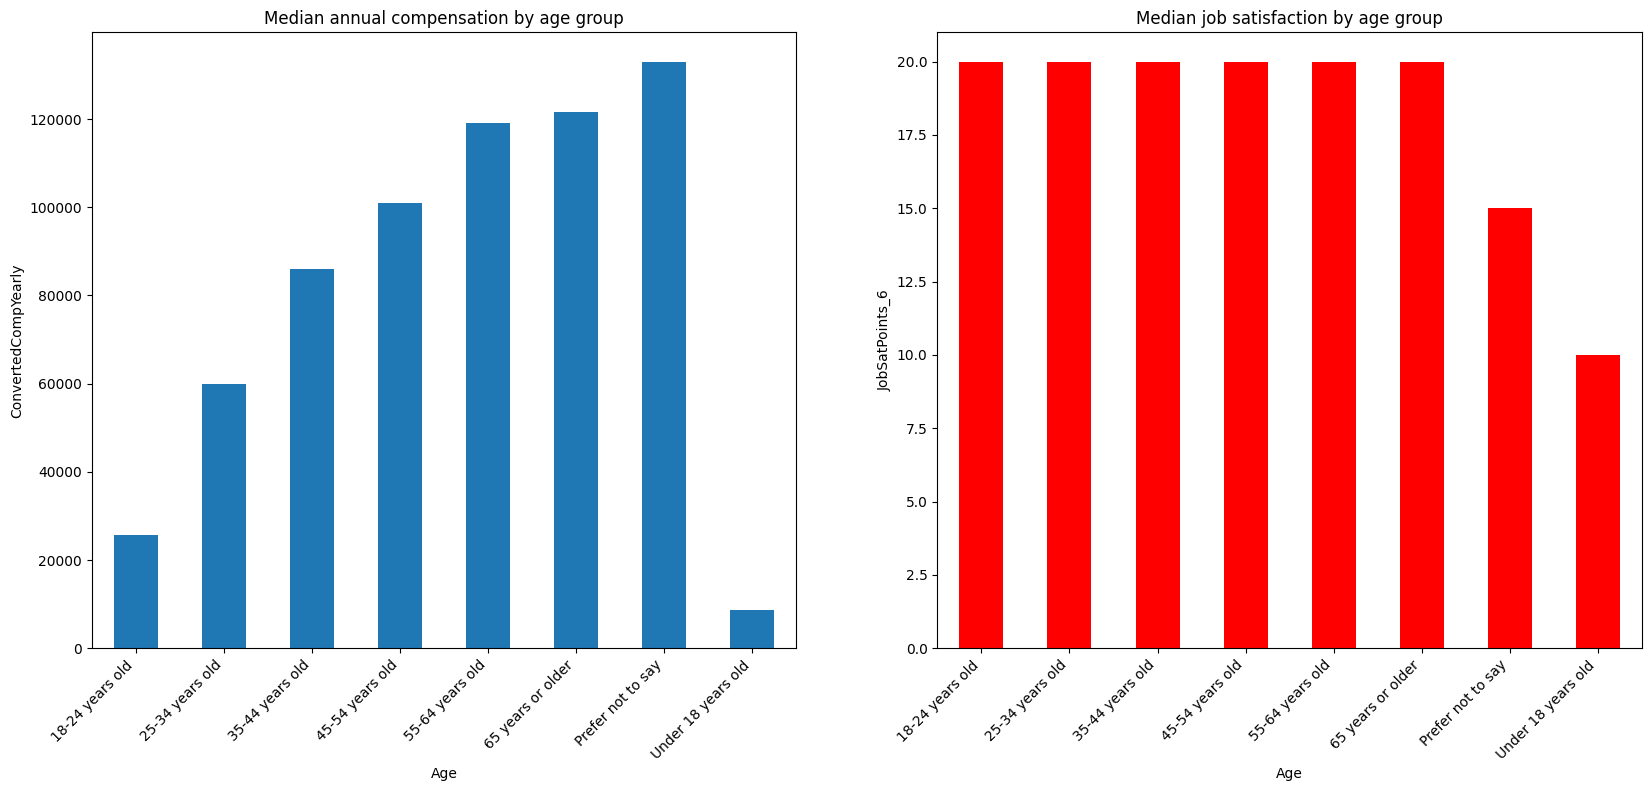

In [10]:
#let's get a specific dataset for this analysis, without missing values
df_ccy_js_age = df[['Age', 'JobSatPoints_6', 'ConvertedCompYearly']].dropna()
#let's group by Age getting the median of the job satisfaction and annual compensation columns
df_ccy_js_age_grouped = df_ccy_js_age.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']].median()
#let's plot the two charts
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
df_ccy_js_age_grouped['ConvertedCompYearly'].plot(kind='bar', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title("Median annual compensation by age group")
axes[0].set_ylabel('ConvertedCompYearly')
df_ccy_js_age_grouped['JobSatPoints_6'].plot(kind='bar', ax=axes[1], color='red')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title("Median job satisfaction by age group")
axes[1].set_ylabel('JobSatPoints_6')
plt.show()

### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


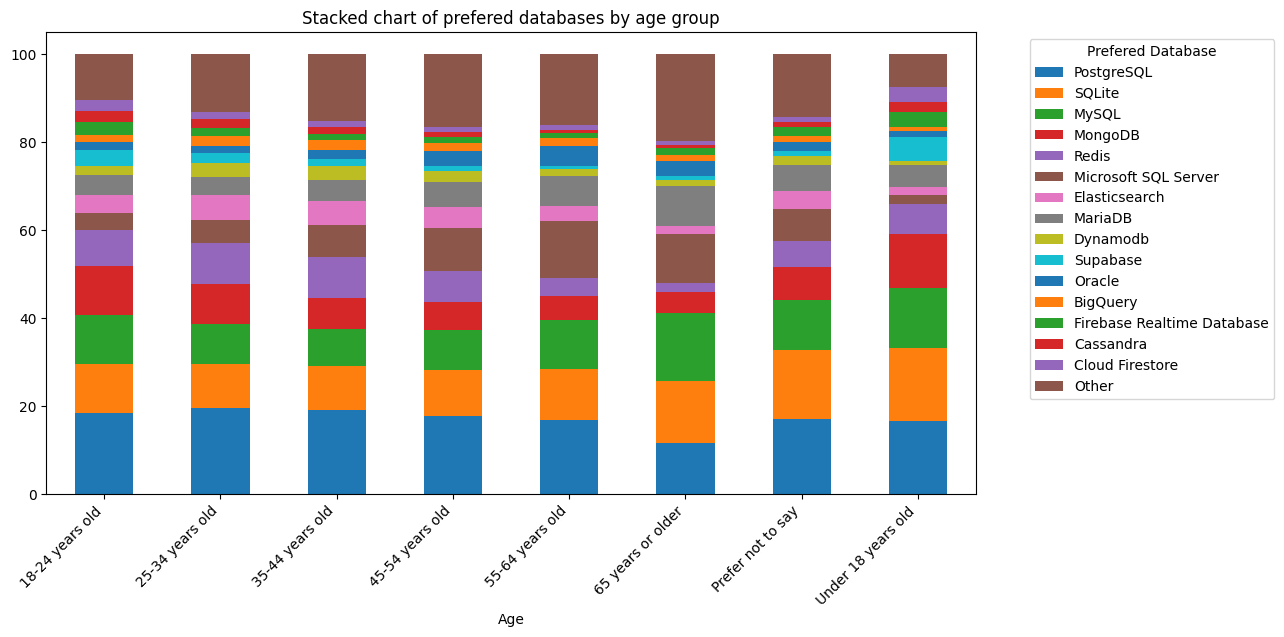

In [11]:
#let's get a specific dataset for this analysis, without missing values
df_db_age = df[['Age', 'DatabaseWantToWorkWith']].dropna()
#let's expand the dataframe by creating one row for each database when we have multiple options in DatabaseWantToWorkWith
df_db_age['Database'] = df_db_age['DatabaseWantToWorkWith'].str.split(';') # create a new column with a list of all database options
df_db_age = df_db_age.explode('Database') # replicate rows with more than one database in this new column
#There are too many databases to plot a meaningful chart. let's consider only the top 15, which are 86% of preferences
db_top15 = df_db_age['Database'].value_counts().head(15).index.tolist()
#let's cross tab age and db preference
db_pref_by_age = pd.crosstab(df_db_age['Age'], df_db_age['Database'])
#let's consider a dataframe with the top  15 databases, and a columm'Others' which sums row wise all the other databases
# Identify the other columns
other_cols = [c for c in db_pref_by_age.columns if c not in db_top15]
# Build the new dataframe
db_pref_by_age_new = db_pref_by_age[db_top15].astype(float).copy()
db_pref_by_age_new['Other'] = db_pref_by_age[other_cols].sum(axis=1).astype(float)
#let's create a new column with the sum of each row, and calculate the proportions by age group
db_pref_by_age_new['row_sum'] = db_pref_by_age_new.sum(axis=1)
for row in db_pref_by_age_new.index.tolist():
    db_pref_by_age_new.loc[row] = db_pref_by_age_new.loc[row] / db_pref_by_age_new.loc[row, 'row_sum'] * 100
db_pref_by_age_new = db_pref_by_age_new.drop(columns='row_sum')
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
db_pref_by_age_new.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Stacked chart of prefered databases by age group')
plt.legend(title='Prefered Database', bbox_to_anchor=(1.05, 1))
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


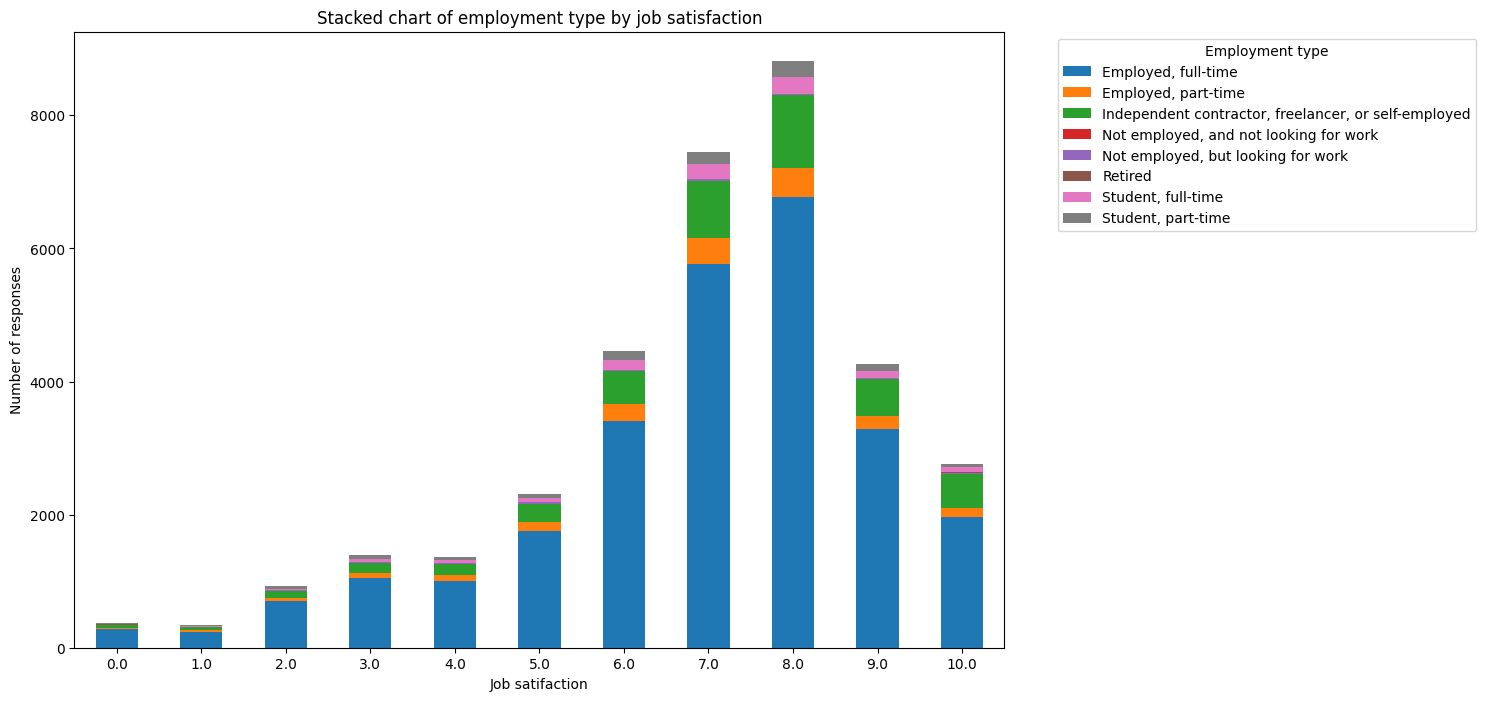

In [12]:
#let's get a specific dataset for this analysis, without missing values
df_emp_jsat = df[['Employment', 'JobSat']].dropna()
#Employment is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_emp_jsat = df_emp_jsat.assign(EmpType=df_emp_jsat['Employment'].str.split(';'))
df_emp_jsat = df_emp_jsat.explode('EmpType')
#let's cross tab job satisfaction and and employment type
emptype_by_jsat = pd.crosstab(df_emp_jsat['JobSat'], df_emp_jsat['EmpType'])
#let's plot the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
emptype_by_jsat.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
plt.title('Stacked chart of employment type by job satisfaction')
plt.legend(title='Employment type', bbox_to_anchor=(1.05, 1))
plt.xlabel('Job satifaction')
plt.ylabel('Number of responses')
plt.show()

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


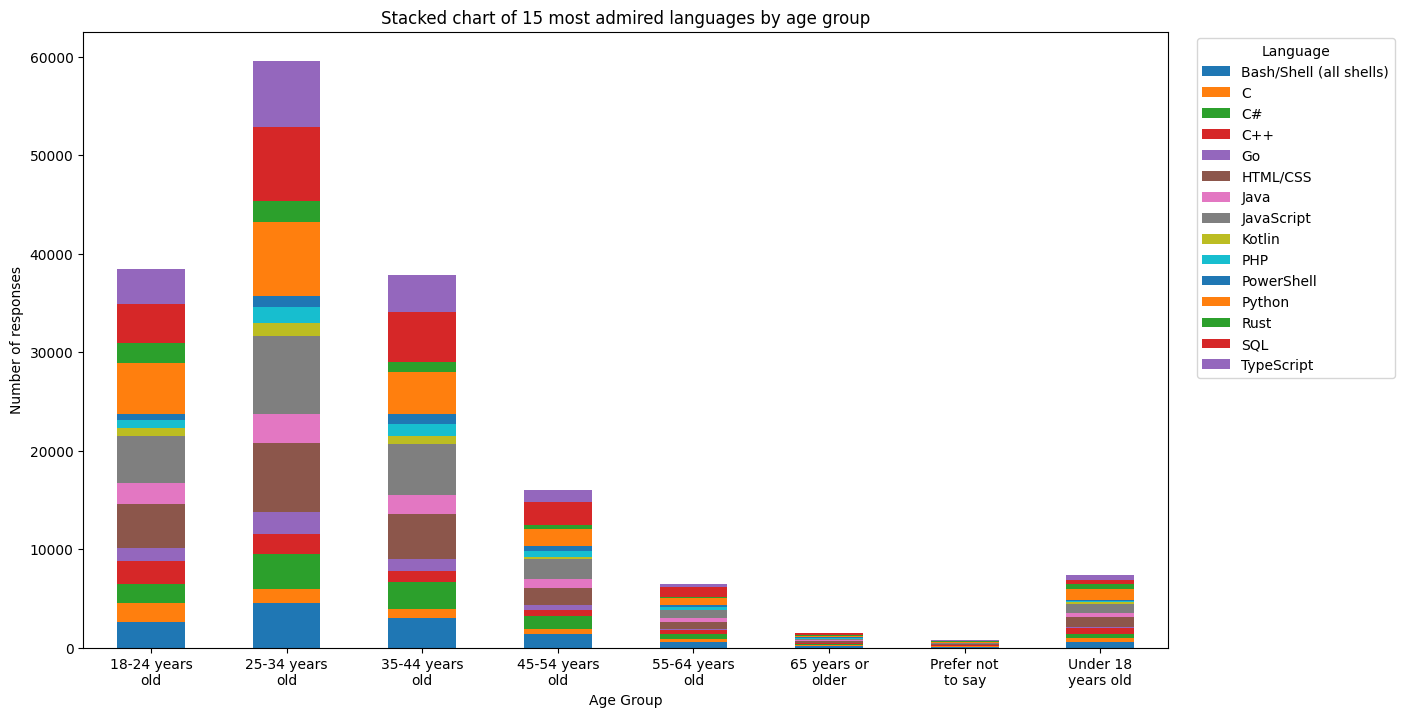

In [13]:
#let's get a specific dataset for this analysis, without missing values
df_age_la = df[['Age', 'LanguageAdmired']].dropna()
#LanguageAdmired is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_age_la = df_age_la.assign(Language=df_age_la['LanguageAdmired'].str.split(';'))
df_age_la = df_age_la.explode('Language')
#There are too many languages to plot a meaningful chart. let's consider only the top 15
lg_top15 = df_age_la['Language'].value_counts().head(15).index.tolist()
filtered_df_age_la = df_age_la[df_age_la['Language'].isin(lg_top15)].copy()
#let's cross tab age and language
language_by_age = pd.crosstab(filtered_df_age_la['Age'], filtered_df_age_la['Language'])
#let's plot the stacked bar chart
wrapped_labels = [textwrap.fill(label, width=12) for label in language_by_age.index]
fig, ax = plt.subplots(figsize=(14, 8))
language_by_age.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')
plt.title('Stacked chart of 15 most admired languages by age group')
ax.legend(title='Language', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel('Age Group')
plt.ylabel('Number of responses')
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


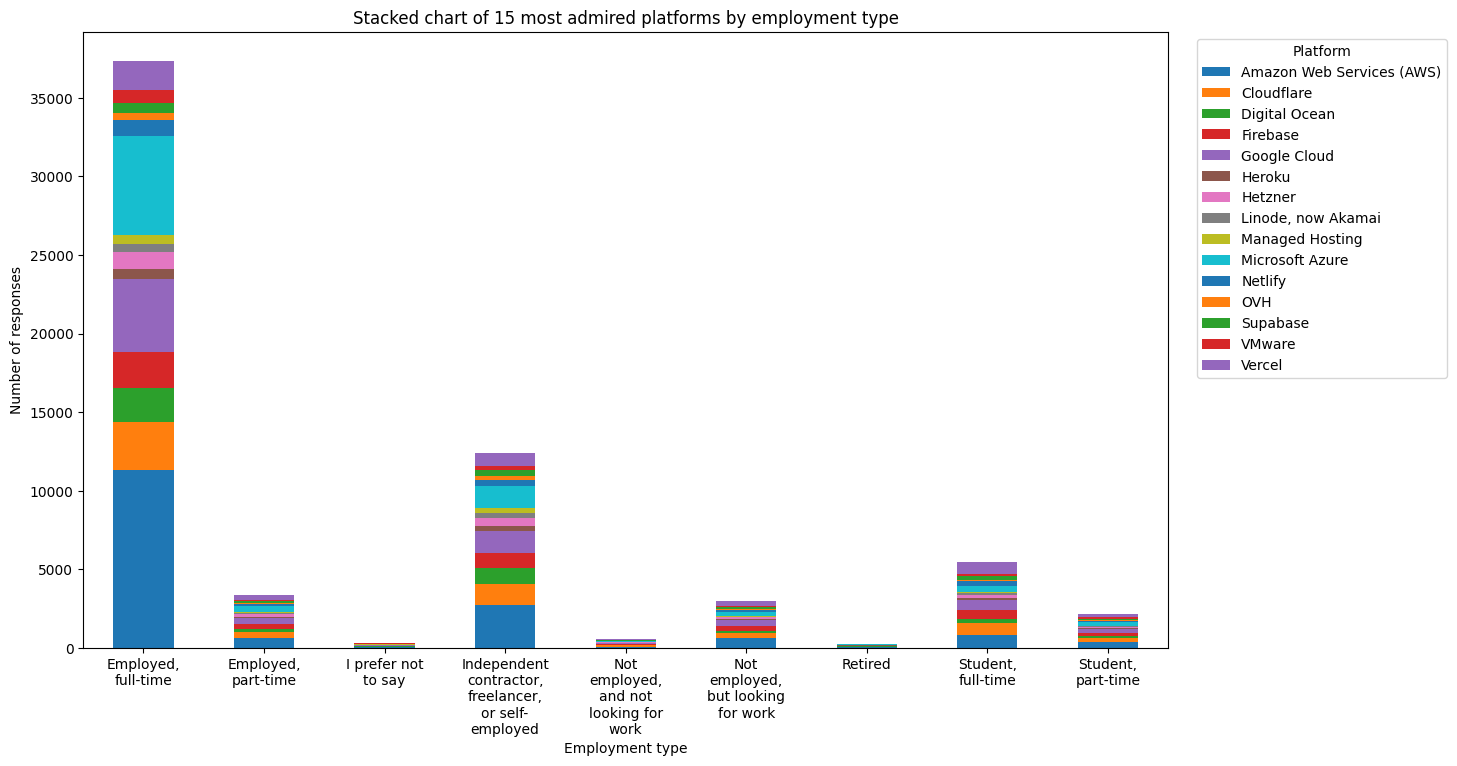

In [14]:
#let's get a specific dataset for this analysis, without missing values
df_et_pa = df[['Employment', 'PlatformAdmired']].dropna()
#Platform Admired is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_et_pa = df_et_pa.assign(Platform=df_et_pa['PlatformAdmired'].str.split(';'))
df_et_pa = df_et_pa.explode('Platform')
#Employment is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_et_pa = df_et_pa.assign(EmpType=df_et_pa['Employment'].str.split(';'))
df_et_pa = df_et_pa.explode('EmpType')
#There are too many platforms to plot a meaningful chart. let's consider only the top 15
pt_top15 = df_et_pa['Platform'].value_counts().head(15).index.tolist()
filtered_df_et_pa = df_et_pa[df_et_pa['Platform'].isin(pt_top15)].copy()
#let's cross tab employment type and platform
platform_by_employment = pd.crosstab(filtered_df_et_pa['EmpType'], filtered_df_et_pa['Platform'])
#let's plot the stacked bar chart
wrapped_labels = [textwrap.fill(label, width=12) for label in platform_by_employment.index]
fig, ax = plt.subplots(figsize=(14, 8))
platform_by_employment.plot(kind='bar', stacked=True, ax=ax)
ax.set_xticklabels(wrapped_labels, rotation=0, ha='center')
plt.title('Stacked chart of 15 most admired platforms by employment type')
ax.legend(title='Platform', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel('Employment type')
plt.ylabel('Number of responses')
plt.show()

### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
